# MSFT Next-Day Direction Predictor — Iteration 3

**Author:** Lucan den Dekker
**Project:** ADSAI Group 15 Block D Capstone
**Date:** 2026-05-20

---

**Improvements over Iteration 2**

| Change | Reason |
|---|---|
| 2019 cutoff removed — full 2015–2026 dataset used | Training set grows from ~1000 to ~2200 rows; tree models need more data to generalise |
| Neutral threshold lowered from ±0.5 % to ±0.2 % | More labelled rows; fewer days discarded as "too small to matter" |
| `lag_spy_return` added — S&P 500 (SPY) previous-day return | MSFT moves strongly with the broad market; sector direction is a meaningful predictor |

| Section | Content |
|---|---|
| 0 | Imports and Setup |
| 1 | Load Data |
| 2 | Feature Engineering |
| 3 | Train/Test Split & Scaling |
| 4 | Baseline Model |
| 5 | Logistic Regression |
| 6 | Random Forest |
| 7 | XGBoost |
| 8 | Model Comparison |
| 9 | Error Analysis |
| 10 | TimeSeriesSplit Cross-Validation |
| 11 | Business Value Interpretation |


In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib yfinance

Note: you may need to restart the kernel to use updated packages.


---
## Section 0 — Imports and Setup

`RANDOM_SEED = 42` is applied to every stochastic component for full reproducibility.
`RobustScaler` is preferred over `StandardScaler` because financial returns contain
extreme outliers (e.g. COVID-19 crash) that distort standard-deviation normalisation.


In [2]:
# Standard library
import warnings
import logging
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Scikit-learn
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# XGBoost
from xgboost import XGBClassifier
import xgboost as xgb_lib

# Persistence
import joblib

# Reproducibility
RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Logging — timestamps + severity levels persist in saved notebook outputs
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("msft_modelling")

# Plot style
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("seaborn-darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13


def find_project_root(marker: str = "README.md") -> Path:
    """Walk up the directory tree until a marker file is found.

    Parameters
    ----------
    marker : str
        Filename expected at the repository root.

    Returns
    -------
    Path
        Absolute path to the repository root.
    """
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    logger.warning("Project root not found; falling back to cwd.")
    return current


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "msft-forecaster" / "data" / "processed" / "msft_merged.csv"
MODELS_DIR = PROJECT_ROOT / "models" / "lucan"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Project root : %s", PROJECT_ROOT)
logger.info("Data path    : %s", DATA_PATH)
logger.info("Models dir   : %s", MODELS_DIR)


2026-05-20 17:08:15 | INFO | Project root : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15
2026-05-20 17:08:15 | INFO | Data path    : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\msft-forecaster\data\processed\msft_merged.csv
2026-05-20 17:08:15 | INFO | Models dir   : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan


---
## Section 1 — Load Data

**Change from it2:** the 2019 cutoff is removed. All available data from 2015
is used. In it2 the 2019 filter cut the training set to ~1000 rows — too few for
Random Forest and XGBoost to learn generalisable patterns. Using the full history
doubles the training data to ~2200 rows.


In [3]:
def load_data(path: Path) -> pd.DataFrame:
    """Load the MSFT merged CSV and return a date-indexed DataFrame.

    Parameters
    ----------
    path : Path
        Absolute path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame with a DatetimeIndex sorted ascending.

    Raises
    ------
    FileNotFoundError
        If the CSV file does not exist.
    ValueError
        If no date column is detected.
    """
    if not path.exists():
        raise FileNotFoundError(f"Data file not found: {path}")

    df = pd.read_csv(path)

    # Detect date column regardless of capitalisation
    date_col = next(
        (c for c in df.columns if c.lower() in ("date", "datetime", "timestamp")),
        None,
    )
    if date_col is None:
        raise ValueError(f"No date column found. Columns: {list(df.columns)}")

    df[date_col] = pd.to_datetime(df[date_col])
    df.set_index(date_col, inplace=True)
    df.index.name = "Date"
    df.sort_index(inplace=True)
    return df


df_raw = load_data(DATA_PATH)
logger.info(
    "Loaded: shape=%s | %s to %s",
    df_raw.shape,
    df_raw.index.min().date(),
    df_raw.index.max().date(),
)

missing = int(df_raw.isnull().sum().sum())
if missing > 0:
    logger.warning("%d missing values found; dropping affected rows.", missing)
    df_raw = df_raw.dropna()
else:
    logger.info("No missing values found.")

# No date cutoff in it3 — full 2015-2026 history used to maximise training data
logger.info("Using full dataset: %d rows", len(df_raw))
print(df_raw.head())


2026-05-20 17:08:15 | INFO | Loaded: shape=(2818, 9) | 2015-02-17 to 2026-04-30
2026-05-20 17:08:15 | INFO | No missing values found.
2026-05-20 17:08:15 | INFO | Using full dataset: 2818 rows


             Open     High    Low   Close      Volume   gold_close  oil_close  \
Date                                                                            
2015-02-17  43.97  44.0000  43.19  43.580  33695149.0  1208.099976  53.529999   
2015-02-18  43.63  43.7000  43.39  43.530  27111657.0  1199.699951  52.139999   
2015-02-19  43.18  43.5263  43.05  43.500  27556420.0  1207.099976  51.160000   
2015-02-20  43.51  43.8800  43.29  43.855  29721133.0  1204.400024  50.340000   
2015-02-23  43.70  44.1900  43.65  44.150  32518754.0  1200.300049  49.450001   

              vix   spy_close  
Date                           
2015-02-17  15.80  174.000732  
2015-02-18  15.45  174.017288  
2015-02-19  15.29  173.893082  
2015-02-20  14.30  174.936493  
2015-02-23  14.56  174.911667  


---
## Section 2 — Feature Engineering

**Changes from it2:**

1. **Neutral threshold lowered to ±0.2 %** — in it2, days with a next-day return
   between −0.5 % and +0.5 % were discarded as neutral. Lowering the threshold to
   ±0.2 % retains more labelled days, giving the models more signal to learn from.

2. **`lag_spy_return` added** — the S&P 500 (SPY) previous-day return captures
   broad market direction. MSFT correlates ~0.7 with SPY; when the market was down
   yesterday, MSFT is more likely to continue falling. This is the strongest
   single macro signal available from end-of-day data.

| Feature | Type | Description |
|---|---|---|
| `rsi_14` | Momentum oscillator | Overbought/oversold signal (0–100) |
| `momentum_5` | 5-day return % | Short-term price momentum |
| `momentum_10` | 10-day return % | Medium-term price momentum |
| `daily_return` | 1-day return % | Today's intraday direction |
| `price_range_pct` | Volatility | (High−Low)/Close — normalised intraday range |
| `close_to_sma5_pct` | Trend deviation | Distance from 5-day MA (%) |
| `close_to_sma10_pct` | Trend deviation | Distance from 10-day MA (%) |
| `sma_crossover` | Trend signal | SMA5/SMA10 — golden/death cross ratio |
| `rolling_std_5` | Volatility | 5-day rolling standard deviation |
| `volume_ratio` | Volume signal | Today's volume / 20-day average volume |
| `lag_gold_return` | Macro | Yesterday's gold % change |
| `lag_oil_return` | Macro | Yesterday's oil % change |
| `lag_vix_1` | Macro | Yesterday's VIX (real daily, yfinance) |
| `lag_spy_return` | Macro / market | Yesterday's SPY % return — broad market direction |

**Target:** next-day return > +0.2 % → UP (1), < −0.2 % → DOWN (0), neutral excluded.


In [4]:
# Neutral zone threshold — lowered from 0.5% (it2) to 0.2% to retain more labelled days
NEUTRAL_THRESHOLD: float = 0.2


def _detect_column(df: pd.DataFrame, candidates: list) -> str:
    """Return the first column name matching any candidate (case-insensitive).

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    candidates : list of str
        Ordered list of expected column names (lowercase).

    Returns
    -------
    str
        The actual column name as it appears in df.

    Raises
    ------
    KeyError
        If none of the candidates match any column.
    """
    col_lower = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in col_lower:
            return col_lower[name]
    raise KeyError(f"None of {candidates} found in columns: {list(df.columns)}")


def _rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """Compute RSI using Wilder's exponential smoothing.

    Values above 70 indicate overbought conditions (potential reversal down);
    values below 30 indicate oversold conditions (potential reversal up).

    Parameters
    ----------
    series : pd.Series
        Daily close price series.
    window : int
        Look-back period (standard: 14 trading days).

    Returns
    -------
    pd.Series
        RSI values in the range [0, 100].
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def engineer_features(df: pd.DataFrame, threshold: float = NEUTRAL_THRESHOLD) -> pd.DataFrame:
    """Add scale-invariant technical and macro features, plus binary target.

    All features use only data available at close on day t to prevent lookahead
    bias. Absolute price levels are replaced with ratio/percentage features.

    Parameters
    ----------
    df : pd.DataFrame
        Raw merged MSFT dataframe with a DatetimeIndex.
    threshold : float
        Minimum absolute next-day return (%) to classify as UP or DOWN.
        Days within ±threshold are excluded as neutral.

    Returns
    -------
    pd.DataFrame
        DataFrame with engineered features and integer 'target' column.
        Neutral days and NaN rows are dropped.
    """
    df = df.copy()

    close = df[_detect_column(df, ["close", "msft_close", "adj close", "adj_close"])]
    high = df[_detect_column(df, ["high", "msft_high"])]
    low = df[_detect_column(df, ["low", "msft_low"])]
    volume = df[_detect_column(df, ["volume", "msft_volume"])]
    gold = df[_detect_column(df, ["gold_close", "gold close", "gold", "gc=f_close"])]
    oil = df[_detect_column(df, ["oil_close", "oil close", "oil", "cl=f_close", "wti_close"])]
    vix = df[_detect_column(df, ["vix", "^vix", "vix_close"])]
    spy = df[_detect_column(df, ["spy_close", "spy"])]

    # Rolling MAs used as denominators for ratio features
    sma5 = close.rolling(5).mean()
    sma10 = close.rolling(10).mean()

    # Momentum: returns over 1, 5, and 10 days
    df["daily_return"] = close.pct_change() * 100
    df["momentum_5"] = close.pct_change(5) * 100
    df["momentum_10"] = close.pct_change(10) * 100

    # RSI(14): overbought/oversold oscillator
    df["rsi_14"] = _rsi(close)

    # MA deviation: how far today's close is from short/medium-term trend
    df["close_to_sma5_pct"] = (close - sma5) / sma5 * 100
    df["close_to_sma10_pct"] = (close - sma10) / sma10 * 100

    # Golden/death cross: ratio > 1 is bullish, < 1 is bearish
    df["sma_crossover"] = sma5 / sma10

    # Volatility features
    df["price_range_pct"] = (high - low) / close * 100
    df["rolling_std_5"] = close.rolling(5).std()

    # Volume: ratio to 20-day average highlights unusual trading activity
    df["volume_ratio"] = volume / volume.rolling(20).mean()

    # Macro lag features (shifted by 1 day to prevent lookahead bias)
    df["lag_gold_return"] = gold.pct_change().shift(1) * 100
    df["lag_oil_return"] = oil.pct_change().shift(1) * 100
    df["lag_vix_1"] = vix.shift(1)

    # Broad market direction: SPY previous-day return (MSFT correlates ~0.7 with SPY)
    df["lag_spy_return"] = spy.pct_change().shift(1) * 100

    # Binary target: next-day return direction with configurable neutral zone
    next_day_return = (close.shift(-1) - close) / close * 100
    df["target"] = np.select(
        [next_day_return > threshold, next_day_return < -threshold],
        [1, 0],
        default=np.nan,
    )

    df = df.dropna(subset=["target"])
    df["target"] = df["target"].astype(int)
    df = df.dropna()

    class_counts = df["target"].value_counts().sort_index()
    logger.info(
        "Threshold=%.1f%%  Class balance  DOWN(0): %d | UP(1): %d",
        threshold,
        class_counts.get(0, 0),
        class_counts.get(1, 0),
    )
    logger.info("Dataset shape after feature engineering: %s", df.shape)
    return df


FEATURE_COLUMNS = [
    "rsi_14",
    "momentum_5",
    "momentum_10",
    "daily_return",
    "price_range_pct",
    "close_to_sma5_pct",
    "close_to_sma10_pct",
    "sma_crossover",
    "rolling_std_5",
    "volume_ratio",
    "lag_gold_return",
    "lag_oil_return",
    "lag_vix_1",
    "lag_spy_return",
]

df = engineer_features(df_raw)
print(df[FEATURE_COLUMNS[:6]].head(6))


2026-05-20 17:08:15 | INFO | Threshold=0.2%  Class balance  DOWN(0): 1082 | UP(1): 1273
2026-05-20 17:08:15 | INFO | Dataset shape after feature engineering: (2355, 24)


               rsi_14  momentum_5  momentum_10  daily_return  price_range_pct  \
Date                                                                            
2015-03-16  30.638147   -3.010502    -5.287147      0.434993         0.866218   
2015-03-17  33.264509   -0.797050    -3.662200      0.324832         1.630891   
2015-03-18  46.317583    1.238685    -1.289049      1.930687         3.529412   
2015-03-19  43.850640    3.083862    -1.913709     -0.505882         0.875015   
2015-03-24  51.800656    2.890035     2.069950      0.105005         0.979021   
2015-03-25  36.824780   -2.447059    -1.238685     -3.356643         3.581766   

            close_to_sma5_pct  
Date                           
2015-03-16          -0.081743  
2015-03-17           0.404556  
2015-03-18           2.087387  
2015-03-19           0.957406  
2015-03-24           0.506044  
2015-03-25          -2.391939  


---
## Section 3 — Train/Test Split & Feature Scaling

A **time-based 80/20 split** preserves chronological order.
`RobustScaler` is fitted **only on the training set** to prevent data leakage.
With the full dataset (~2800 labelled rows after neutral exclusion) the training
set is now ~2× larger than in it2, which should benefit ensemble models most.


In [5]:
def split_and_scale(
    df: pd.DataFrame,
    feature_cols: list,
    train_size: float = 0.80,
    models_dir: Path = MODELS_DIR,
) -> tuple:
    """Time-based train/test split with RobustScaler fitted on training data only.

    Parameters
    ----------
    df : pd.DataFrame
        Feature-engineered dataset with DatetimeIndex.
    feature_cols : list of str
        Column names to use as model features.
    train_size : float
        Fraction of rows allocated to training (chronological order preserved).
    models_dir : Path
        Directory where the fitted scaler is persisted.

    Returns
    -------
    tuple
        X_train_scaled, X_test_scaled, y_train, y_test, df_train, df_test, scaler
    """
    split_idx = int(len(df) * train_size)
    df_train = df.iloc[:split_idx]
    df_test = df.iloc[split_idx:]

    logger.info(
        "Train: %d rows | %s to %s",
        len(df_train),
        df_train.index.min().date(),
        df_train.index.max().date(),
    )
    logger.info(
        "Test:  %d rows | %s to %s",
        len(df_test),
        df_test.index.min().date(),
        df_test.index.max().date(),
    )

    X_train = df_train[feature_cols]
    X_test = df_test[feature_cols]
    y_train = df_train["target"]
    y_test = df_test["target"]

    # Fit scaler only on train; transform both splits with the same parameters
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    scaler_path = models_dir / "scaler_lucan_it3.pkl"
    joblib.dump(scaler, scaler_path)
    logger.info("Scaler saved to %s", scaler_path)

    return X_train_scaled, X_test_scaled, y_train, y_test, df_train, df_test, scaler


X_train_scaled, X_test_scaled, y_train, y_test, df_train, df_test, scaler = (
    split_and_scale(df, FEATURE_COLUMNS)
)
print(f"X_train: {X_train_scaled.shape}  |  balance: {y_train.value_counts().to_dict()}")
print(f"X_test:  {X_test_scaled.shape}   |  balance: {y_test.value_counts().to_dict()}")


2026-05-20 17:08:15 | INFO | Train: 1884 rows | 2015-03-16 to 2024-01-30
2026-05-20 17:08:15 | INFO | Test:  471 rows | 2024-01-31 to 2026-04-29
2026-05-20 17:08:15 | INFO | Scaler saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\scaler_lucan_it3.pkl


X_train: (1884, 14)  |  balance: {1: 1022, 0: 862}
X_test:  (471, 14)   |  balance: {1: 251, 0: 220}


---
## Section 4 — Baseline Model (Majority-Class Classifier)

A majority-class baseline establishes the **performance floor**.
Any model that cannot beat this threshold provides no predictive value.


In [6]:
def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    """Compute weighted classification metrics and return as a results dict.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    y_pred : array-like
        Predicted labels.
    model_name : str
        Human-readable identifier used in logging and the results table.

    Returns
    -------
    dict
        Keys: 'Model', 'Accuracy', 'Precision', 'Recall', 'F1'.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    logger.info(
        "%s  Acc=%.4f  Prec=%.4f  Rec=%.4f  F1=%.4f",
        model_name, acc, prec, rec, f1,
    )
    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    }


def plot_confusion_matrix(y_true, y_pred, model_name: str) -> None:
    """Plot a seaborn heatmap confusion matrix.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    y_pred : array-like
        Predicted labels.
    model_name : str
        Used as the plot title.
    """
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["DOWN (0)", "UP (1)"],
        yticklabels=["DOWN (0)", "UP (1)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


# Majority-class baseline: always predicts the most frequent class
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

baseline_metrics = evaluate_model(y_test, y_pred_dummy, "Baseline (Majority Class)")
print(classification_report(y_test, y_pred_dummy, target_names=["DOWN", "UP"]))


2026-05-20 17:08:15 | INFO | Baseline (Majority Class)  Acc=0.5329  Prec=0.2840  Rec=0.5329  F1=0.3705


              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00       220
          UP       0.53      1.00      0.70       251

    accuracy                           0.53       471
   macro avg       0.27      0.50      0.35       471
weighted avg       0.28      0.53      0.37       471



---
## Section 5 — Iteration 1: Logistic Regression

`class_weight='balanced'` corrects class imbalance by adjusting each sample's
loss contribution inversely proportional to class frequency.


2026-05-20 17:08:15 | INFO | Logistic Regression fitted.
2026-05-20 17:08:15 | INFO | Logistic Regression  Acc=0.4862  Prec=0.4983  Rec=0.4862  F1=0.4737


              precision    recall  f1-score   support

        DOWN       0.46      0.65      0.54       220
          UP       0.53      0.34      0.41       251

    accuracy                           0.49       471
   macro avg       0.50      0.50      0.48       471
weighted avg       0.50      0.49      0.47       471



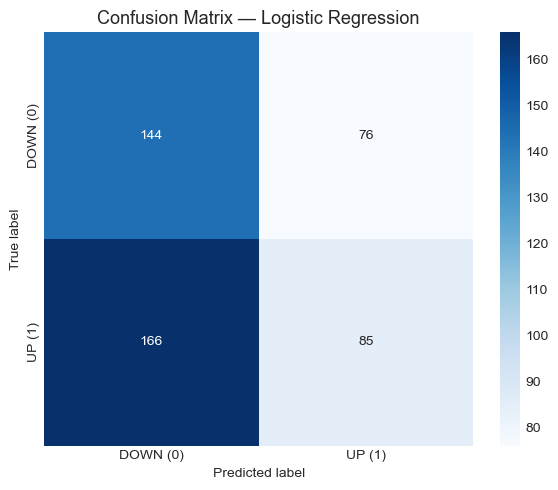

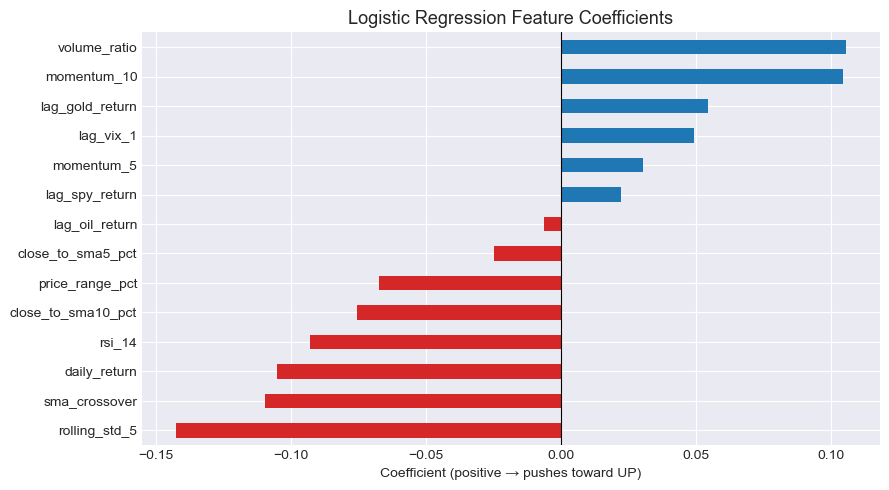

2026-05-20 17:08:16 | INFO | Logistic Regression saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\logistic_regression_lucan_it3.pkl


In [7]:
def train_logistic_regression(
    X_train: np.ndarray,
    y_train: pd.Series,
    random_state: int = 42,
) -> LogisticRegression:
    """Fit a logistic regression classifier with balanced class weights.

    Parameters
    ----------
    X_train : np.ndarray
        Scaled training features.
    y_train : pd.Series
        Binary training labels (0 = DOWN, 1 = UP).
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    LogisticRegression
        Fitted model.
    """
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=random_state,
    )
    model.fit(X_train, y_train)
    logger.info("Logistic Regression fitted.")
    return model


lr_model = train_logistic_regression(X_train_scaled, y_train, RANDOM_SEED)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_metrics = evaluate_model(y_test, y_pred_lr, "Logistic Regression")

print(classification_report(y_test, y_pred_lr, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

# Coefficient chart: positive value = pushes prediction toward UP
coef_df = pd.Series(lr_model.coef_[0], index=FEATURE_COLUMNS).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
coef_df.plot(
    kind="barh",
    ax=ax,
    color=["#d62728" if v < 0 else "#1f77b4" for v in coef_df],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Feature Coefficients")
ax.set_xlabel("Coefficient (positive → pushes toward UP)")
plt.tight_layout()
plt.show()

lr_path = MODELS_DIR / "logistic_regression_lucan_it3.pkl"
joblib.dump(lr_model, lr_path)
logger.info("Logistic Regression saved to %s", lr_path)


---
## Section 6 — Iteration 2: Random Forest

`max_depth=6` and `min_samples_leaf=5` prevent individual trees from overfitting.
With ~2× more training data compared to it2, the forest can now learn deeper
patterns without memorising noise.


2026-05-20 17:08:16 | INFO | Random Forest fitted.
2026-05-20 17:08:16 | INFO | Random Forest  Acc=0.4841  Prec=0.4827  Rec=0.4841  F1=0.4832


              precision    recall  f1-score   support

        DOWN       0.45      0.43      0.44       220
          UP       0.52      0.53      0.52       251

    accuracy                           0.48       471
   macro avg       0.48      0.48      0.48       471
weighted avg       0.48      0.48      0.48       471



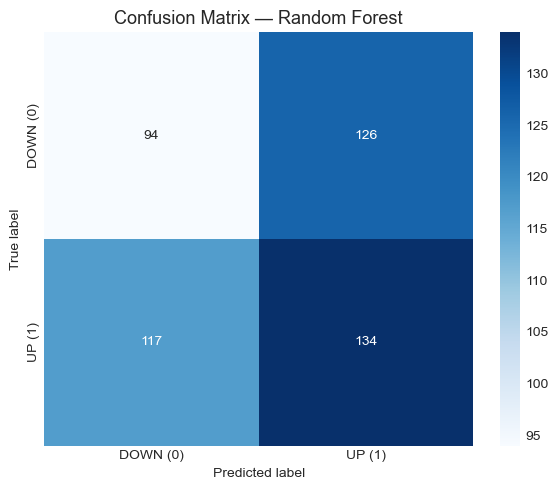

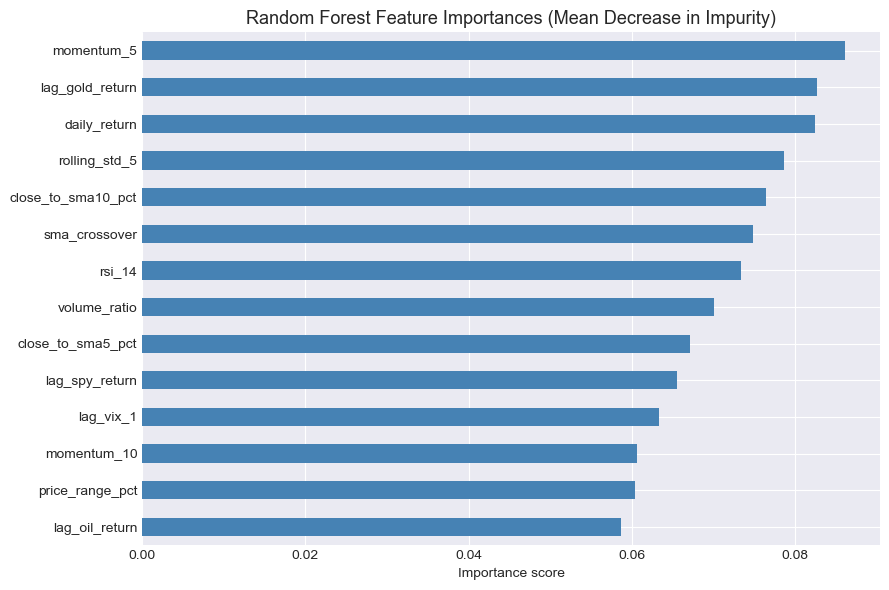

2026-05-20 17:08:17 | INFO | Random Forest saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\random_forest_lucan_it3.pkl


In [8]:
def train_random_forest(
    X_train: np.ndarray,
    y_train: pd.Series,
    random_state: int = 42,
) -> RandomForestClassifier:
    """Fit a Random Forest classifier with anti-overfitting hyperparameters.

    Parameters
    ----------
    X_train : np.ndarray
        Scaled training features.
    y_train : pd.Series
        Binary training labels.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    RandomForestClassifier
        Fitted model.
    """
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=random_state,
    )
    model.fit(X_train, y_train)
    logger.info("Random Forest fitted.")
    return model


rf_model = train_random_forest(X_train_scaled, y_train, RANDOM_SEED)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest")

print(classification_report(y_test, y_pred_rf, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

# Feature importance: mean decrease in impurity across all trees
importance_series = (
    pd.Series(rf_model.feature_importances_, index=FEATURE_COLUMNS)
    .sort_values(ascending=True)
)
fig, ax = plt.subplots(figsize=(9, 6))
importance_series.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest Feature Importances (Mean Decrease in Impurity)")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.show()

rf_path = MODELS_DIR / "random_forest_lucan_it3.pkl"
joblib.dump(rf_model, rf_path)
logger.info("Random Forest saved to %s", rf_path)


---
## Section 7 — Iteration 3: XGBoost

`subsample=0.8` and `colsample_bytree=0.8` add stochastic regularisation.
`scale_pos_weight` balances the class gradient signal explicitly.
With more training data, the boosting process should converge to better patterns.


2026-05-20 17:08:17 | INFO | XGBoost fitted (scale_pos_weight=0.843).
2026-05-20 17:08:17 | INFO | XGBoost  Acc=0.5223  Prec=0.5272  Rec=0.5223  F1=0.5222


              precision    recall  f1-score   support

        DOWN       0.49      0.56      0.52       220
          UP       0.56      0.49      0.52       251

    accuracy                           0.52       471
   macro avg       0.52      0.52      0.52       471
weighted avg       0.53      0.52      0.52       471



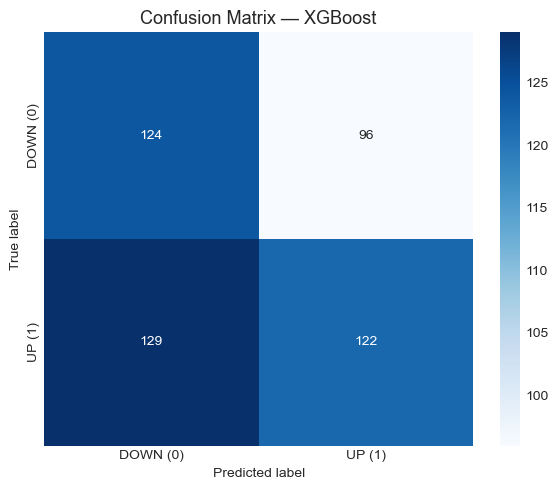

2026-05-20 17:08:17 | INFO | XGBoost saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\xgboost_lucan_it3.pkl


In [9]:
def train_xgboost(
    X_train: np.ndarray,
    y_train: pd.Series,
    random_state: int = 42,
) -> XGBClassifier:
    """Fit an XGBoost classifier with stochastic regularisation.

    subsample and colsample_bytree add randomness per tree reducing variance.
    scale_pos_weight compensates for class imbalance in gradient computation.

    Parameters
    ----------
    X_train : np.ndarray
        Scaled training features.
    y_train : pd.Series
        Binary training labels.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    XGBClassifier
        Fitted model.
    """
    n_down = int((y_train == 0).sum())
    n_up = int((y_train == 1).sum())
    spw = n_down / n_up

    _xgb_major = int(xgb_lib.__version__.split(".")[0])
    params = dict(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric="logloss",
        random_state=random_state,
    )
    if _xgb_major < 2:
        params["use_label_encoder"] = False

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    logger.info("XGBoost fitted (scale_pos_weight=%.3f).", spw)
    return model


xgb_model = train_xgboost(X_train_scaled, y_train, RANDOM_SEED)
y_pred_xgb = xgb_model.predict(X_test_scaled)
xgb_metrics = evaluate_model(y_test, y_pred_xgb, "XGBoost")

print(classification_report(y_test, y_pred_xgb, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost")

xgb_path = MODELS_DIR / "xgboost_lucan_it3.pkl"
joblib.dump(xgb_model, xgb_path)
logger.info("XGBoost saved to %s", xgb_path)


---
## Section 8 — Model Comparison

**F1 (weighted)** is the primary metric. Both false positives (buying into a
losing day) and false negatives (missing a profitable day) carry financial cost.


                    Model  Accuracy  Precision  Recall     F1
Baseline (Majority Class)    0.5329     0.2840  0.5329 0.3705
      Logistic Regression    0.4862     0.4983  0.4862 0.4737
            Random Forest    0.4841     0.4827  0.4841 0.4832
                  XGBoost    0.5223     0.5272  0.5223 0.5222


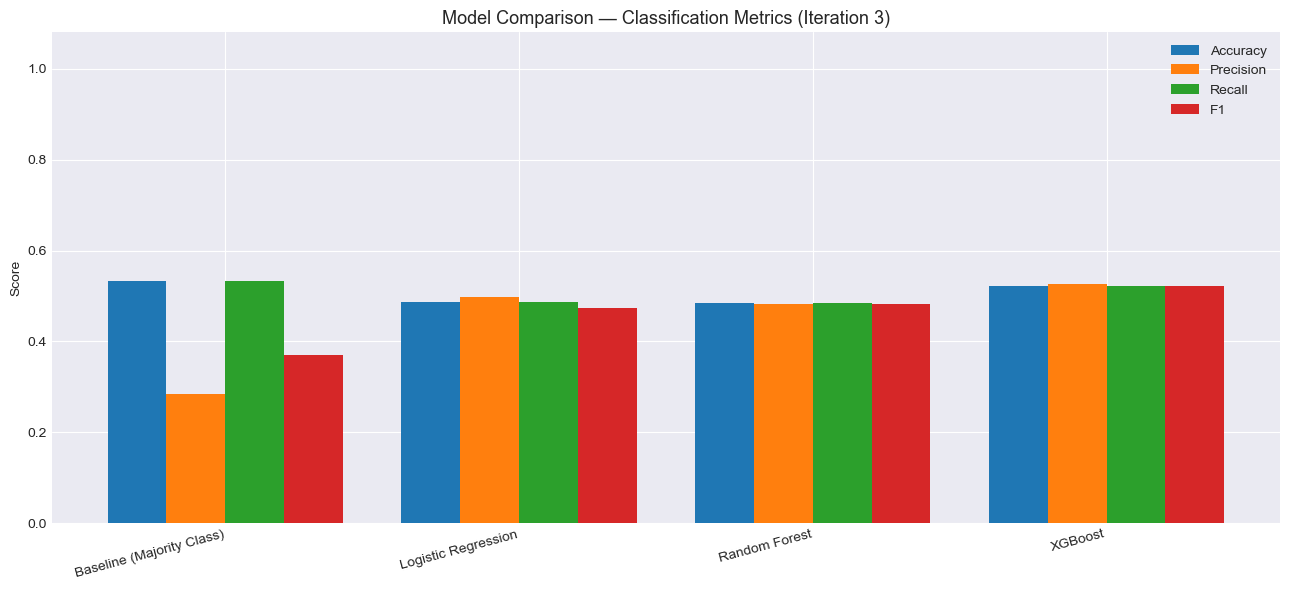

2026-05-20 17:08:17 | INFO | Best model by F1: XGBoost (F1=0.5222)



Best model: XGBoost   F1 = 0.5222


In [10]:
results_df = pd.DataFrame([
    baseline_metrics,
    lr_metrics,
    rf_metrics,
    xgb_metrics,
])
print(results_df.to_string(index=False))

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(results_df))
width = 0.20

fig, ax = plt.subplots(figsize=(13, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Classification Metrics (Iteration 3)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df["F1"].idxmax()]
BEST_MODEL_NAME: str = best_row["Model"]
logger.info("Best model by F1: %s (F1=%.4f)", BEST_MODEL_NAME, best_row["F1"])
print(f"\nBest model: {BEST_MODEL_NAME}   F1 = {best_row['F1']:.4f}")


---
## Section 9 — Error Analysis

Temporal error overlay reveals whether errors cluster around specific market
regimes or are randomly distributed across the test window.


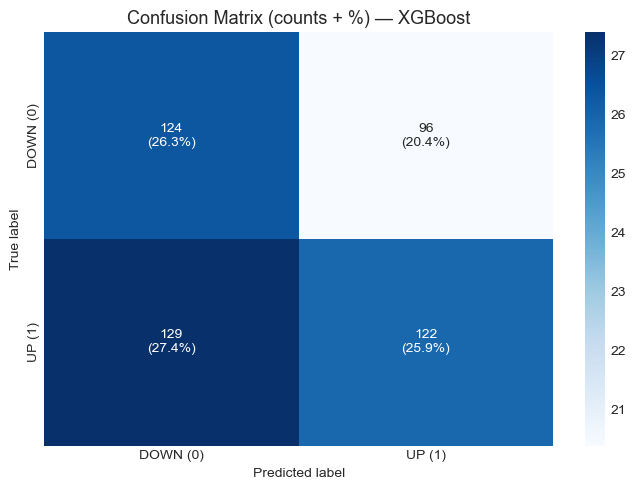

2026-05-20 17:08:18 | INFO | False positives (pred UP, actual DOWN): 96
2026-05-20 17:08:18 | INFO | False negatives (pred DOWN, actual UP): 129


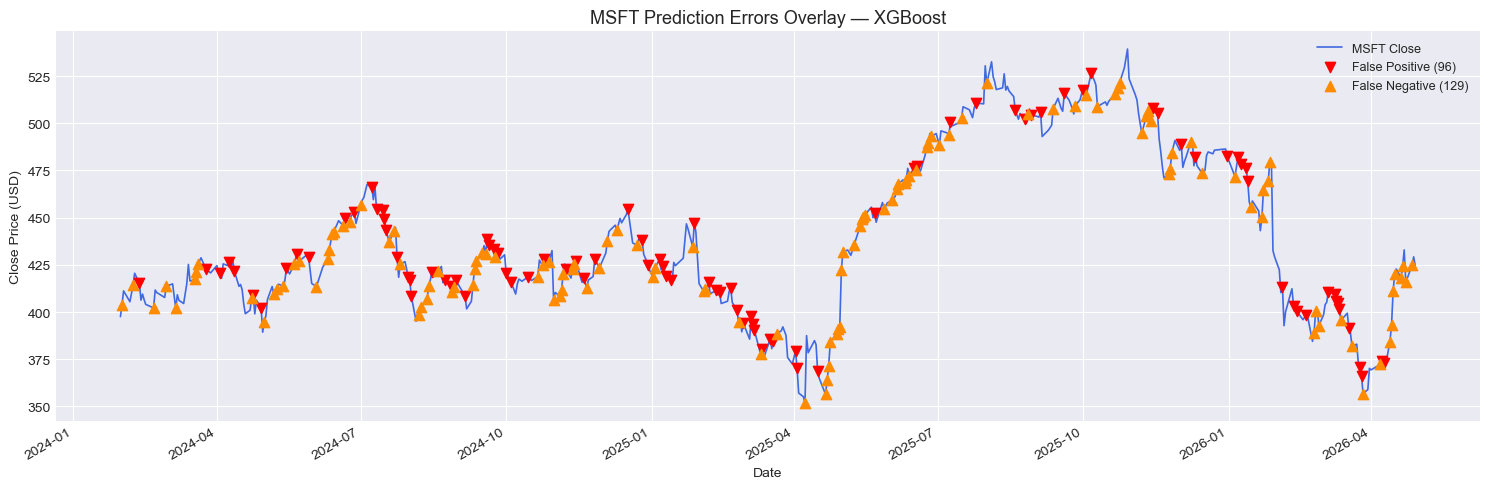

In [11]:
_model_preds = {
    "Baseline (Majority Class)": y_pred_dummy,
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
}
y_pred_best = _model_preds[BEST_MODEL_NAME]

# Confusion matrix with raw counts and percentages
cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum() * 100
annot = np.array([
    [f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_pct, annot=annot, fmt="", cmap="Blues",
    xticklabels=["DOWN (0)", "UP (1)"],
    yticklabels=["DOWN (0)", "UP (1)"],
    ax=ax,
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion Matrix (counts + %) — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()

y_pred_series = pd.Series(y_pred_best, index=df_test.index, name="pred")
false_pos = df_test.index[(y_pred_series == 1) & (y_test == 0)]
false_neg = df_test.index[(y_pred_series == 0) & (y_test == 1)]

logger.info("False positives (pred UP, actual DOWN): %d", len(false_pos))
logger.info("False negatives (pred DOWN, actual UP): %d", len(false_neg))

close_col = _detect_column(df, ["close", "msft_close", "adj close", "adj_close"])

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_test.index, df_test[close_col],
        color="royalblue", linewidth=1.2, label="MSFT Close")
ax.scatter(false_pos, df_test.loc[false_pos, close_col],
           color="red", marker="v", s=55, zorder=5,
           label=f"False Positive ({len(false_pos)})")
ax.scatter(false_neg, df_test.loc[false_neg, close_col],
           color="darkorange", marker="^", s=55, zorder=5,
           label=f"False Negative ({len(false_neg)})")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.set_title(f"MSFT Prediction Errors Overlay — {BEST_MODEL_NAME}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Section 10 — TimeSeriesSplit Cross-Validation

`TimeSeriesSplit` preserves chronological order so each fold's test set always
lies in the future relative to its training set — no lookahead bias.
The `Pipeline` re-fits `RobustScaler` on each fold's training data to prevent leakage.


2026-05-20 17:08:19 | INFO | TimeSeriesSplit CV (5 folds)  mean=0.4946  std=0.0163


F1 per fold : [0.489, 0.526, 0.4914, 0.479, 0.4875]
Mean F1     : 0.4946
Std dev     : 0.0163


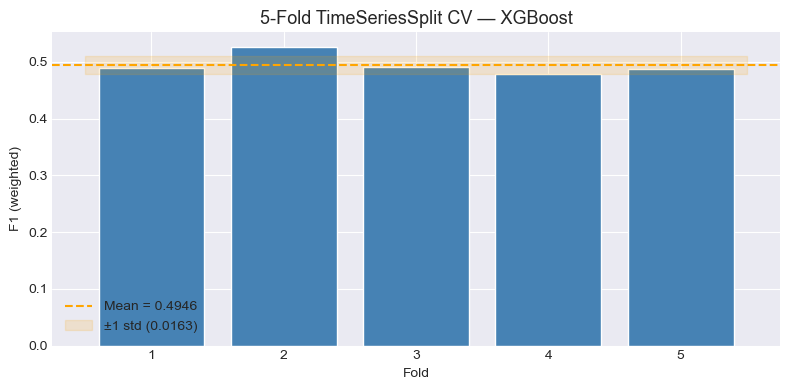

In [12]:
def run_cross_validation(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    scoring: str = "f1_weighted",
) -> np.ndarray:
    """TimeSeriesSplit cross-validation with per-fold RobustScaler.

    Parameters
    ----------
    model : estimator
        Scikit-learn compatible model (cloned per fold, not modified in place).
    X : pd.DataFrame
        Unscaled feature matrix.
    y : pd.Series
        Target labels.
    n_splits : int
        Number of TimeSeriesSplit folds.
    scoring : str
        Scikit-learn metric name.

    Returns
    -------
    np.ndarray
        Per-fold scores.
    """
    # Pipeline re-fits scaler on each fold's training data to prevent leakage
    cv_pipeline = Pipeline([
        ("scaler", RobustScaler()),
        ("model", clone(model)),
    ])
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = cross_val_score(cv_pipeline, X, y, cv=tscv, scoring=scoring)
    logger.info(
        "TimeSeriesSplit CV (%d folds)  mean=%.4f  std=%.4f",
        n_splits, scores.mean(), scores.std(),
    )
    return scores


_model_objs = {
    "Baseline (Majority Class)": dummy,
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}
best_model_obj = _model_objs[BEST_MODEL_NAME]

cv_scores = run_cross_validation(best_model_obj, df[FEATURE_COLUMNS], df["target"])

print(f"F1 per fold : {[round(float(s), 4) for s in cv_scores]}")
print(f"Mean F1     : {cv_scores.mean():.4f}")
print(f"Std dev     : {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cv_scores) + 1), cv_scores, color="steelblue", edgecolor="white")
ax.axhline(
    cv_scores.mean(), color="orange", linestyle="--", linewidth=1.5,
    label=f"Mean = {cv_scores.mean():.4f}",
)
ax.fill_between(
    [0.5, len(cv_scores) + 0.5],
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.15, color="orange",
    label=f"±1 std ({cv_scores.std():.4f})",
)
ax.set_xlabel("Fold")
ax.set_ylabel("F1 (weighted)")
ax.set_title(f"5-Fold TimeSeriesSplit CV — {BEST_MODEL_NAME}")
ax.set_xticks(range(1, len(cv_scores) + 1))
ax.legend()
plt.tight_layout()
plt.show()


---
## Section 11 — Business Value Interpretation

### What the model predicts and for whom

This model predicts the **binary next-day direction** of MSFT's closing price
(UP or DOWN, excluding ±0.2 % neutral days). It is designed for **retail investors**
using the MSFT Forecaster dashboard as a decision-support tool — not an
automated trading system.

### Interpreting the metrics

| F1 Range | Practical meaning |
|---|---|
| < 0.50 | Worse than a coin flip on this balanced problem — no deployable value |
| 0.50–0.55 | Marginal signal; use only as one factor among many |
| 0.55–0.65 | Genuine directional signal; useful supporting indicator |
| > 0.65 | Strong signal; can justify more weight in a decision framework |

### Limitations

| Limitation | Impact |
|---|---|
| No retraining schedule | Performance degrades as market regimes shift |
| MSFT only | Does not generalise to other stocks without retraining |
| End-of-day data only | Intraday signals and pre-market moves are ignored |
| Earnings / macro events not included | Model is blind to known catalyst dates |
| Neutral days excluded (~10 % at ±0.2 % threshold) | Dashboard must show "no signal" state clearly |

### Dashboard integration

The saved `scaler_lucan_it3.pkl` and best-model `.pkl` allow the Streamlit dashboard to:
1. Load both at startup with `joblib.load()`.
2. Compute the same `FEATURE_COLUMNS` from today's OHLCV + macro + SPY data.
3. Call `model.predict_proba()` to return a confidence score alongside the direction.
4. Display the prediction with an explicit disclaimer that this is not financial advice.
